In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
datos_arbolado= pd.read_pickle("../data/datos_arbolado")

datos_arbolado.head()

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol,ancho_acera_limpio
0,-58.378563,-34.594902,1,NaN,Esmeralda,1000.0,1120.0,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0,5.5
1,-58.381532,-34.592319,1,NaN,Pellegrini Carlos,1300.0,1345.0,Peltophorum dubium,4.5,2.0,Regular,2.0,6.0,5.0,4.5
2,-58.379103,-34.591939,1,NaN,Arroyo,800.0,848.0,Fraxinus pennsylvanica,4,2.0,Regular,1.0,7.0,6.0,4.0
3,-58.380710,-34.591548,1,NaN,Arroyo,900.0,932.0,Fraxinus pennsylvanica,NaN,2.0,Regular,1.0,9.0,29.0,NaN
4,-58.380710,-34.591548,1,NaN,Arroyo,900.0,932.0,Jacaranda mimosifolia,NaN,2.0,Regular,1.0,13.0,8.0,NaN


In [33]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   comuna                 370180 non-null  int64  
 3   manzana                224140 non-null  object 
 4   calle_nombre           370087 non-null  object 
 5   calle_altura           364677 non-null  object 
 6   calle_chapa            363721 non-null  object 
 7   nombre_cientifico      360769 non-null  object 
 8   ancho_acera            367083 non-null  object 
 9   estado_plantera        369983 non-null  float64
 10  ubicacion_plantera     368479 non-null  object 
 11  nivel_plantera         368820 non-null  float64
 12  diametro_altura_pecho  369894 non-null  float64
 13  altura_arbol           365858 non-null  float64
 14  ancho_acera_limpio     367041 non-nu

### Analisar si hay relacion entre diametro y ancho acera

In [34]:
filtro=datos_arbolado['diametro_altura_pecho']<130
diametro_altura_pecho=datos_arbolado[filtro]
filtro2= datos_arbolado['ancho_acera_limpio']<9
diametro_altura_pecho= diametro_altura_pecho[filtro2]

/tmp/ipykernel_36376/1155051726.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  diametro_altura_pecho= diametro_altura_pecho[filtro2]


Axes(0.125,0.11;0.775x0.77)


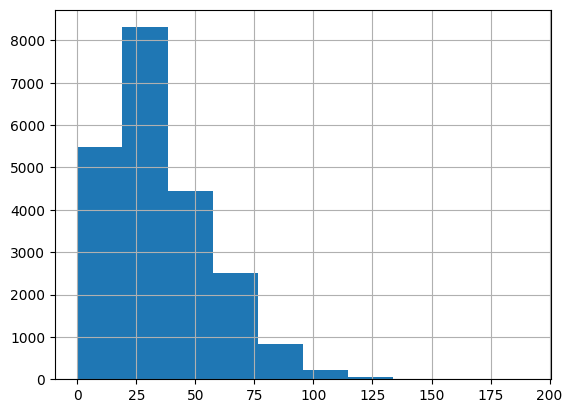

In [35]:

filtro=datos_arbolado['ubicacion_plantera']=='Ochava'
dato=datos_arbolado[filtro]
print(dato['diametro_altura_pecho'].hist())

In [36]:
print(diametro_altura_pecho[diametro_altura_pecho['estado_plantera']==3]['comuna'].value_counts())
print(diametro_altura_pecho['comuna'].value_counts())


comuna
11    5123
10    4750
12    4710
9     4209
15    3782
13    2795
7     2408
4     2028
8     1921
14    1815
5     1304
6     1285
2      568
1      474
3      451
Name: count, dtype: int64
comuna
12    38438
11    36899
9     36056
10    33215
4     31614
15    29224
13    27328
7     25242
14    21338
8     21109
6     15538
5     15135
3     13243
1     11215
2      7026
Name: count, dtype: int64


In [37]:
print(datos_arbolado['nombre_cientifico'].value_counts())
filtro= datos_arbolado['estado_plantera']==3
ancho_limpio= datos_arbolado[filtro]
print(ancho_limpio['nombre_cientifico'].value_counts())

nombre_cientifico
Fraxinus pennsylvanica    133609
Platanus x acerifolia      32319
Ficus benjamina            22508
Tilia x moltkei            15605
Melia azedarach            14901
                           ...  
Prunus serrulata               1
Synadenium grantii             1
Sterculia monosperma           1
Ficus microcarpa               1
Maclura pomifera               1
Name: count, Length: 430, dtype: int64
nombre_cientifico
Fraxinus pennsylvanica           9603
Ficus benjamina                  3396
Melia azedarach                  1783
Lagerstroemia indica             1701
Platanus x acerifolia            1605
                                 ... 
Vallesia glabra                     1
Gleditsia triacanthos inermis       1
Podocarpus sp.                      1
Sambucus peruvianus                 1
Cedrela angustifolia                1
Name: count, Length: 306, dtype: int64


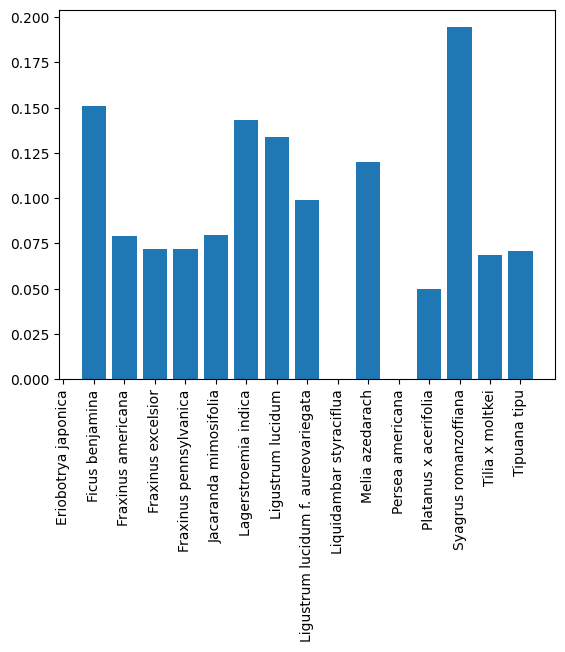

In [39]:
h= ancho_limpio['nombre_cientifico'].value_counts().nlargest(15)/(datos_arbolado['nombre_cientifico'].value_counts().nlargest(15))
plt.Figure(figsize=(10,10))
plt.bar(h.index,h.values)
plt.xticks(rotation=90)
plt.show()
